# Optimal Character Recognition (OCR) with OpenCV
It a Computer Vision technique that we are using for digits classification and identification, for performing it, we will use KNN which detects k nearest neighbors of particular point and classifies that based on them.

## 1. Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

## 2. Importing Dataset

In [ ]:
!wget https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/master/5-OCR/image.png

--2026-03-02 05:05:57--  https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/master/5-OCR/image.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1060366 (1.0M) [image/png]
Saving to: ‘image.png.1’

image.png.1         100%[===================>]   1.01M  --.-KB/s    in 0.01s   

2026-03-02 05:05:57 (93.4 MB/s) - ‘image.png.1’ saved [1060366/1060366]



In [19]:
image = cv2.imread('image.png.1')

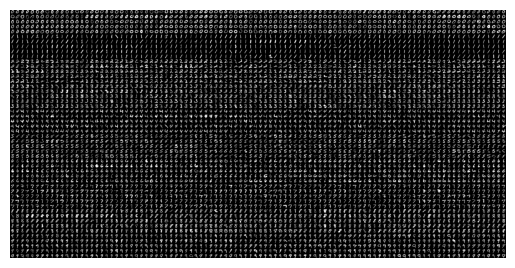

In [20]:
# Display the image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## 3. Gray Scale Conversion

In [21]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

## 4. Divide the image into 5000 dimensions 20x20

In [22]:
division = [np.hsplit(i, 100) for i in np.vsplit(gray_image, 50)]

In [29]:
len(division), len(division[0])

(50, 100)

## 5. Covert into numpy array size (50, 100, 20, 20)

In [23]:
numpy_array = np.array(division)

In [24]:
numpy_array.shape

(50, 100, 20, 20)

## 6. Training and Test Set

In [33]:
numpy_array[:, :50].shape

(50, 50, 20, 20)

In [40]:
X_train = numpy_array[:, :50].reshape(-1, 400).astype(np.float32)
X_test = numpy_array[:, 50:].reshape(-1, 400).astype(np.float32)

In [ ]:
X_train.shape

(2500, 400)

In [ ]:
X_test.shape

(2500, 400)

## 7. Creating Labels

In [52]:
labels = np.arange(10)
y_train = np.repeat(labels, 250)[:, np.newaxis]
y_test = np.repeat(labels, 250)[:, np.newaxis]

## 8. Bilding and Train the Model

In [53]:
model = cv2.ml.KNearest_create()
model.train(X_train, cv2.ml.ROW_SAMPLE, y_train)

True

## 9. Evaluation

In [54]:
ret, output, neighbours, distance = model.findNearest(X_test, k=3)
matched = output == y_test
correct_output = np.count_nonzero(matched)

In [55]:
accuracy = (correct_output*100.0)/(output.size)
print(f"Accuracy: {accuracy}")

Accuracy: 91.64


## 10. Making a Prediction

In [61]:
# Select a random test sample and make a prediction
sample_index = 100
test_sample = X_test[sample_index].reshape(1, -1)
ret, prediction, neighbours, distance = model.findNearest(test_sample, k=3)

print(f"Predicted Digit: {int(prediction[0][0])}")
print(f"Actual Digit: {int(y_test[sample_index][0])}")
print(f"Neighbors: {neighbours}")
print(f"Distance: {distance}")

Predicted Digit: 0
Actual Digit: 0
Neighbors: [[0. 0. 0.]]
Distance: [[511465. 714787. 728455.]]


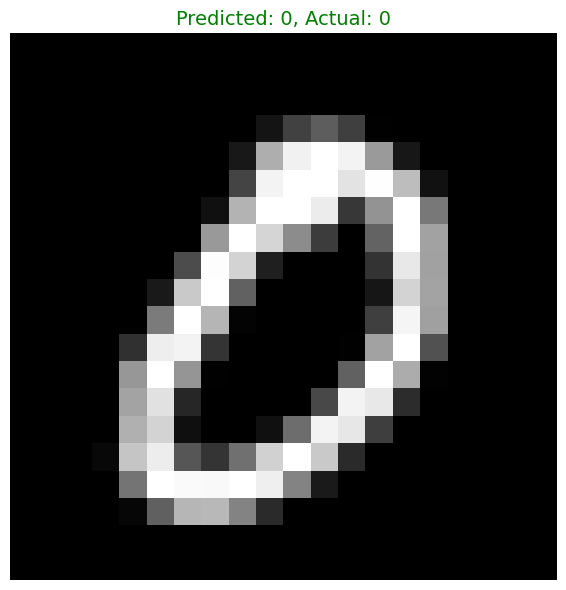

In [64]:
# Visualize the predicted digit
digit_image = X_test[sample_index].reshape(20, 20)
plt.figure(figsize=(6, 6))
plt.imshow(digit_image, cmap='gray')
color = 'g' if int(prediction[0][0]) == int(y_test[sample_index][0]) else 'r'
plt.title(f'Predicted: {int(prediction[0][0])}, Actual: {int(y_test[sample_index][0])}', fontsize=14, color =color)
plt.axis('off')
plt.tight_layout()
plt.show()